In [2]:
%load_ext autoreload
%autoreload 2

In [108]:
path = '/home/jakejoseph/Desktop/freeMotion-jake-2024-09-17/videos/freeMotionDLC_resnet50_freeMotionSep17shuffle1_120000.csv'
data = pd.read_csv(path, skiprows=3, header=None)


# Define the column structure
parts_count = 12  # Number of body parts tracked
columns = []

# Create meaningful column names
for i in range(parts_count):
    columns.extend([f'part{i}_x', f'part{i}_y', f'part{i}_likelihood'])

# Create a new dataframe with renamed columns
# Skip the first column (index) and use columns 1-36
df_clean = pd.DataFrame()

# Extract x, y, and likelihood values
for i in range(parts_count):
    col_idx = 3*i + 1  # Starting from column 1 (skipping the index column at 0)
    df_clean[f'part{i}_x'] = data[col_idx]
    df_clean[f'part{i}_y'] = data[col_idx + 1]
    df_clean[f'part{i}_likelihood'] = data[col_idx + 2]

# Apply Smoothing

def smooth_data(df, window_size=5):
    """
    Smooths the x, y coordinates of body parts using a rolling mean.
    
    Parameters:
    - df: DataFrame containing x, y coordinates.
    - window_size: Size of the rolling window for smoothing.
    
    Returns:
    - DataFrame with smoothed coordinates.
    """
    for i in range(parts_count):
        x_col = f'part{i}_x'
        y_col = f'part{i}_y'
        
        # Apply rolling mean to smooth the data
        df[x_col] = df[x_col].rolling(window=window_size, min_periods=1).mean()
        df[y_col] = df[y_col].rolling(window=window_size, min_periods=1).mean()
    
    return df


# Interpolation based on likelihood threshold
def interpolate_likelihood(df, threshold=0.5):
    """
    Interpolates the x, y coordinates of body parts based on likelihood.
    
    Parameters:
    - df: DataFrame containing x, y coordinates and likelihoods.
    - threshold: Likelihood threshold for interpolation.
    
    Returns:
    - DataFrame with interpolated coordinates.
    """
    for i in range(parts_count):
        x_col = f'part{i}_x'
        y_col = f'part{i}_y'
        lik_col = f'part{i}_likelihood'
        
        # Interpolate only where likelihood is above the threshold
        df[x_col] = df[x_col].where(df[lik_col] > threshold).interpolate()
        df[y_col] = df[y_col].where(df[lik_col] > threshold).interpolate()
    
    return df

# # Interpolate the DataFrame
df_clean = interpolate_likelihood(df_clean, threshold=0.5)

# Smooth the DataFrame
df_clean = smooth_data(df_clean, window_size=3)



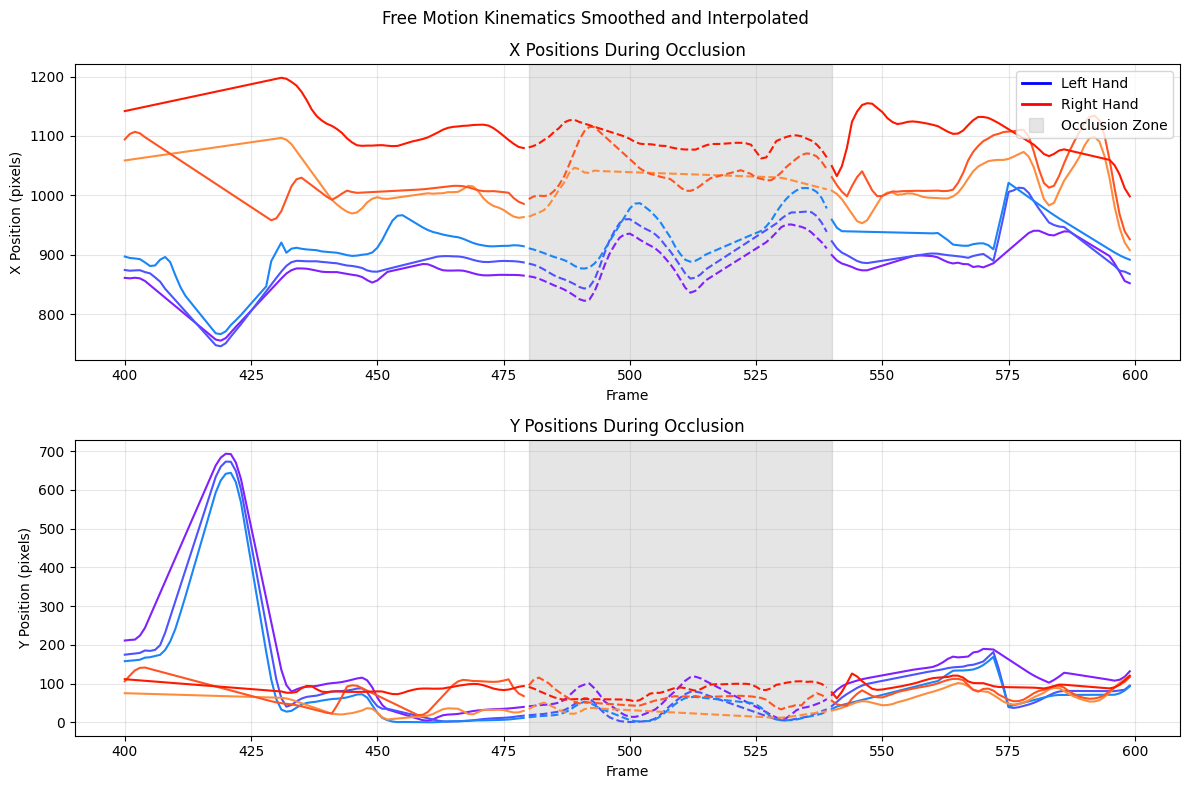

In [109]:
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt

# Extract likelihood columns
likelihood_cols = [col for col in df_clean.columns if 'x' in col]

# Separate first 6 and last 6 lines
first_six = likelihood_cols[:3]
last_six = likelihood_cols[9:]

# Define colors for first_six and last_six
first_six_colors = ['#8120ff', '#4c53ff', '#1a85f7']
last_six_colors = ['#ff8c3d', '#ff5421', '#ff1800']

# Create a figure with 2 subplots vertically aligned
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot X positions in the first subplot
for col, color in zip(first_six, first_six_colors):
    # Plot from 400 to 480 (solid)
    ax1.plot(range(400, 480), df_clean[col][400:480], color=color)
    # Plot from 480 to 540 (dashed)
    ax1.plot(range(480, 540), df_clean[col][480:540], color=color, linestyle='--')
    # Plot from 540 to 600 (solid)
    ax1.plot(range(540, 600), df_clean[col][540:600], color=color)

for col, color in zip(last_six, last_six_colors):
    # Plot from 400 to 480 (solid)
    ax1.plot(range(400, 480), df_clean[col][400:480], color=color)
    # Plot from 480 to 540 (dashed)
    ax1.plot(range(480, 540), df_clean[col][480:540], color=color, linestyle='--')
    # Plot from 540 to 600 (solid)
    ax1.plot(range(540, 600), df_clean[col][540:600], color=color)

ax1.axvspan(480, 540, color='grey', alpha=0.2, label='Occuled Area')
ax1.set_xlabel('Frame')
ax1.set_ylabel('X Position (pixels)')
ax1.set_title('X Positions During Occlusion')
ax1.grid(True, alpha=0.3)

# Plot Y positions in the second subplot with the same dashed line pattern
y_cols_first = [col.replace('_x', '_y') for col in first_six]
y_cols_last = [col.replace('_x', '_y') for col in last_six]

# Plot Y positions in the second subplot
for col, color in zip(y_cols_first, first_six_colors):
    # Plot from 400 to 480 (solid)
    ax2.plot(range(400, 480), df_clean[col][400:480], color=color)
    # Plot from 480 to 540 (dashed)
    ax2.plot(range(480, 540), df_clean[col][480:540], color=color, linestyle='--')
    # Plot from 540 to 600 (solid)
    ax2.plot(range(540, 600), df_clean[col][540:600], color=color)

for col, color in zip(y_cols_last, last_six_colors):
    # Plot from 400 to 480 (solid)
    ax2.plot(range(400, 480), df_clean[col][400:480], color=color)
    # Plot from 480 to 540 (dashed)
    ax2.plot(range(480, 540), df_clean[col][480:540], color=color, linestyle='--')
    # Plot from 540 to 600 (solid)
    ax2.plot(range(540, 600), df_clean[col][540:600], color=color)

ax2.axvspan(480, 540, color='grey', alpha=0.2)
ax2.set_xlabel('Frame')
ax2.set_ylabel('Y Position (pixels)')
ax2.set_title('Y Positions During Occlusion')
ax2.grid(True, alpha=0.3)

plt.suptitle('Free Motion Kinematics Smoothed and Interpolated')

# Add legend
custom_lines = [
    Line2D([0], [0], color='blue', lw=2),
    Line2D([0], [0], color='red', lw=2),
    Line2D([0], [0], color='grey', marker='s', linestyle='none', markersize=10, alpha=0.2)
]
ax1.legend(custom_lines, ['Left Hand', 'Right Hand', 'Occlusion Zone'], loc='upper right')

plt.tight_layout()
plt.savefig('/home/jakejoseph/Desktop/figures/free_motion_kinematics_colored_interp.svg')
plt.show()



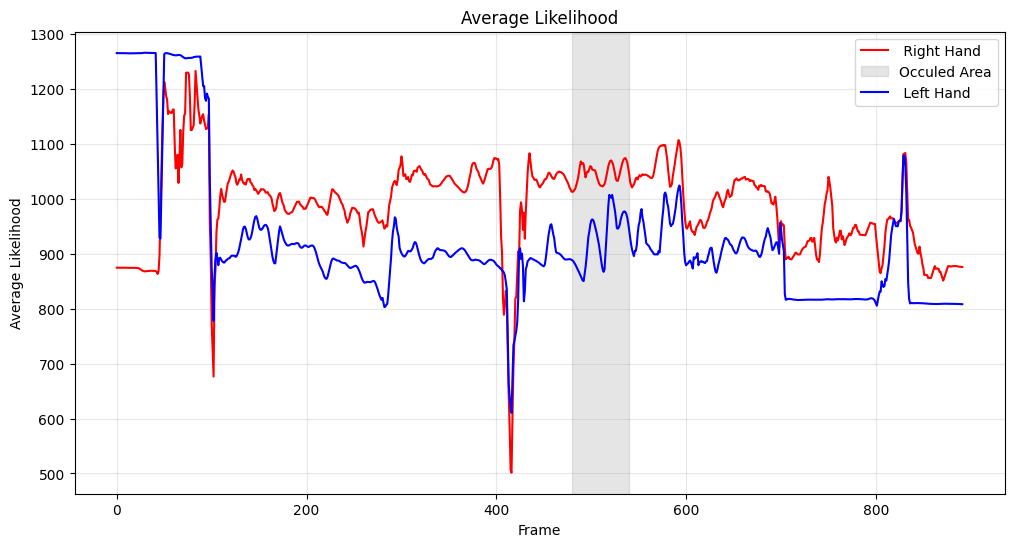

In [71]:
# Plot average likelihood of first 6 parts
plt.figure(figsize=(12, 6))
first_six_avg = df_clean[first_six].mean(axis=1)
last_six_avg = df_clean[last_six].mean(axis=1)
plt.plot(last_six_avg, label=' Right Hand ', color='red')
plt.axvspan(480, 540, color='grey', alpha=0.2,label = 'Occuled Area')  # Add grey area
plt.plot(first_six_avg, label=' Left Hand ', color='blue')
plt.xlabel('Frame')
plt.ylabel('Average Likelihood')
plt.title('Average Likelihood')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()